# German Credit Risk Prediction


In [22]:
# Import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import neural_network


In [23]:
# Load datasets
df = pd.read_csv("german_credit.csv")

df.head()

,Creditability,Account Balance,Duration of Credit Mths,Payment Status of Previous Credit,Purpose,Credit Amount,Value of Savings and Stocks,Length of current employment,Instalment per cent,Sex and Marital Status,...,Duration in Current address,Most valuable available asset,Age,Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [24]:
# Check Missing Values
df.isnull().any()

Creditability                        False
Account Balance                      False
Duration of Credit Mths              False
Payment Status of Previous Credit    False
Purpose                              False
Credit Amount                        False
Value of Savings and Stocks          False
Length of current employment         False
Instalment per cent                  False
Sex and Marital Status               False
Guarantors                           False
Duration in Current address          False
Most valuable available asset        False
Age                                  False
Concurrent Credits                   False
Type of apartment                    False
No of Credits at this Bank           False
Occupation                           False
No of dependents                     False
Telephone                            False
Foreign Worker                       False
dtype: bool

## Exploratory Data Analysis

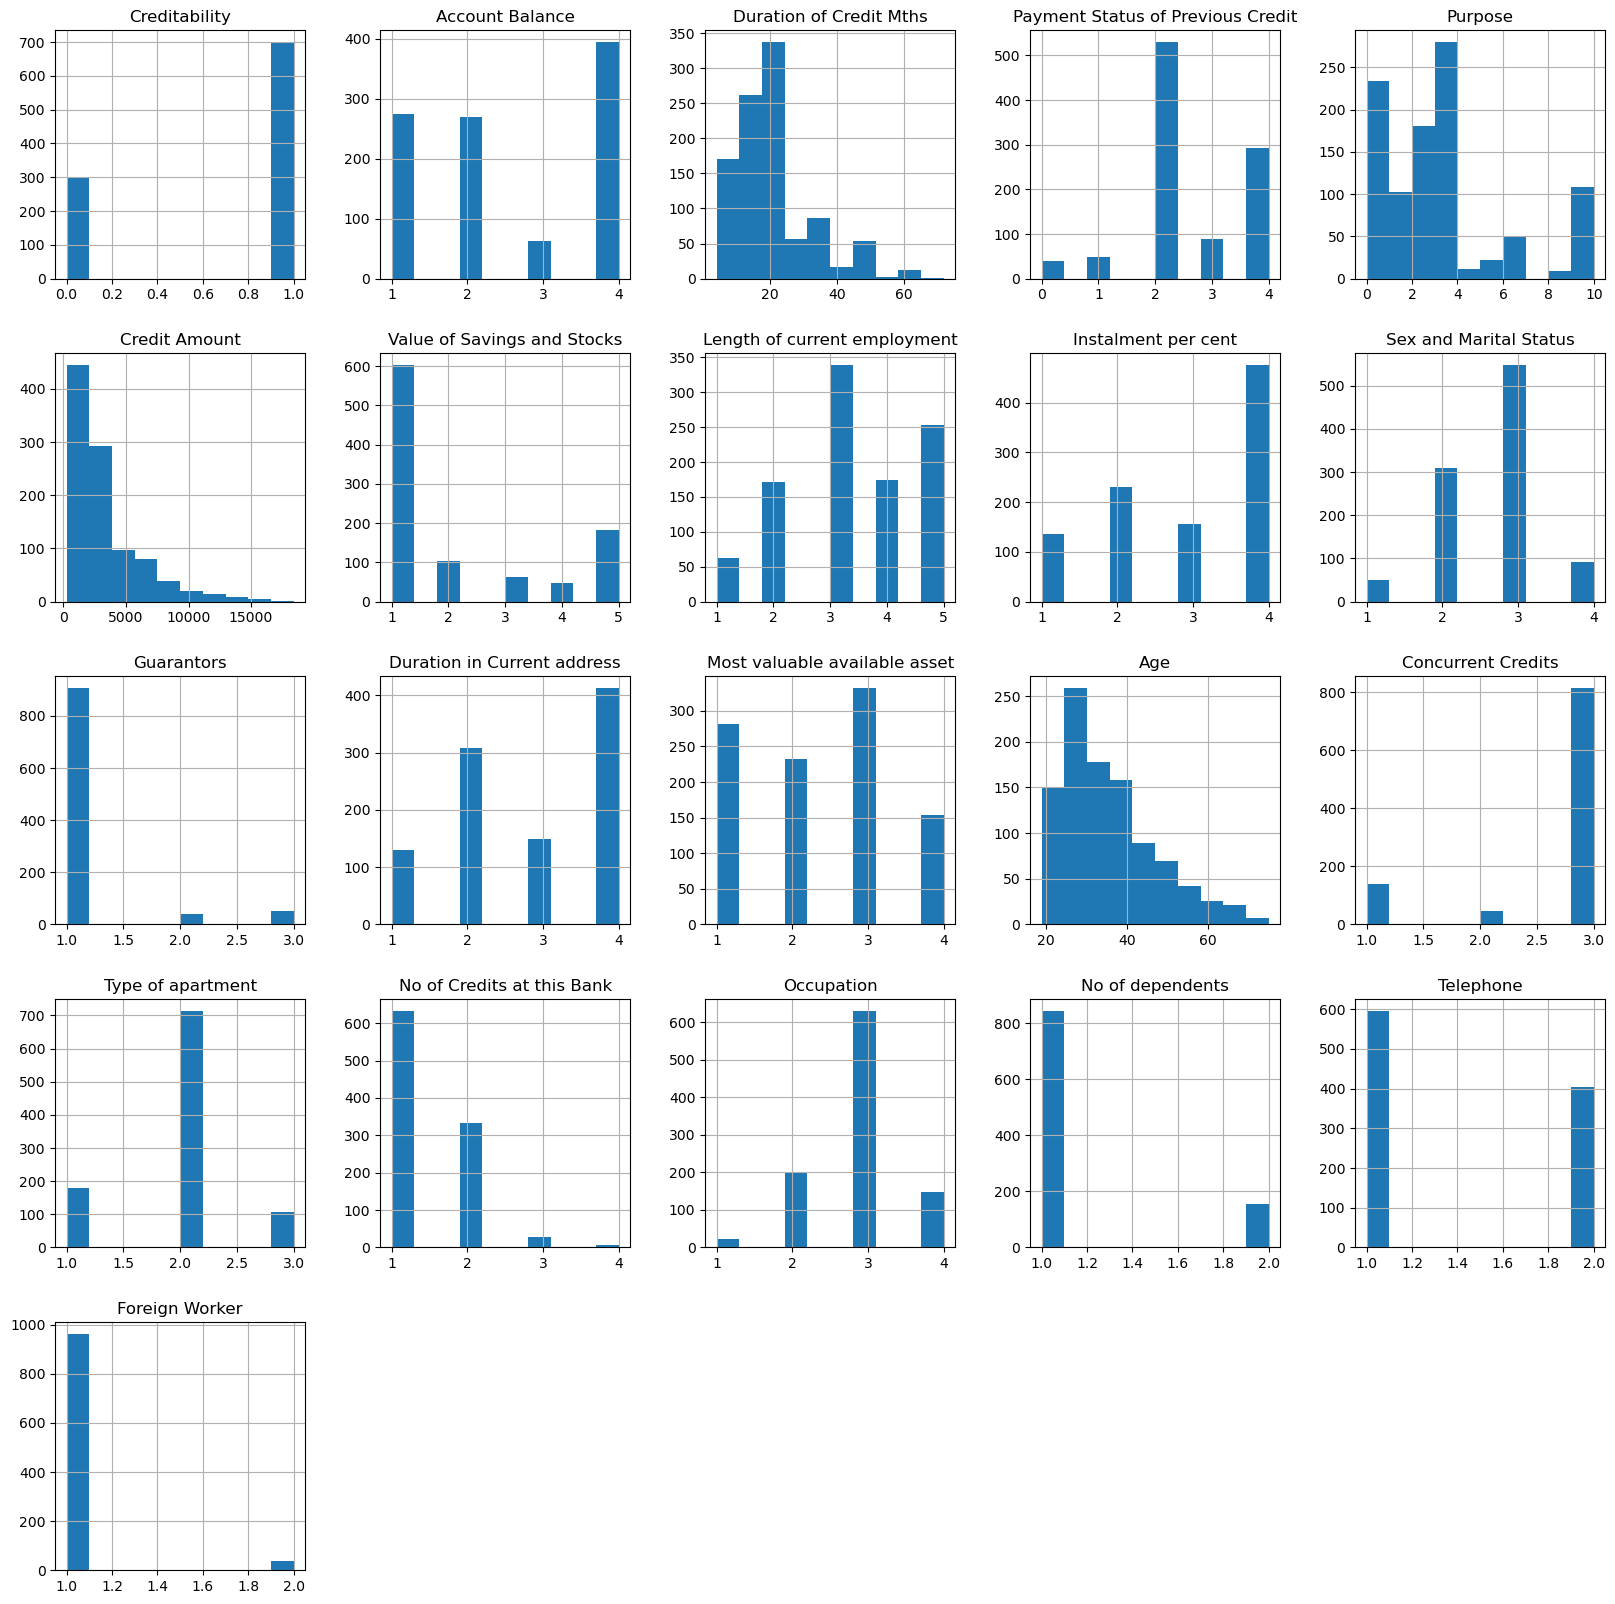

In [25]:
df.hist(figsize=(20, 20))
plt.show()

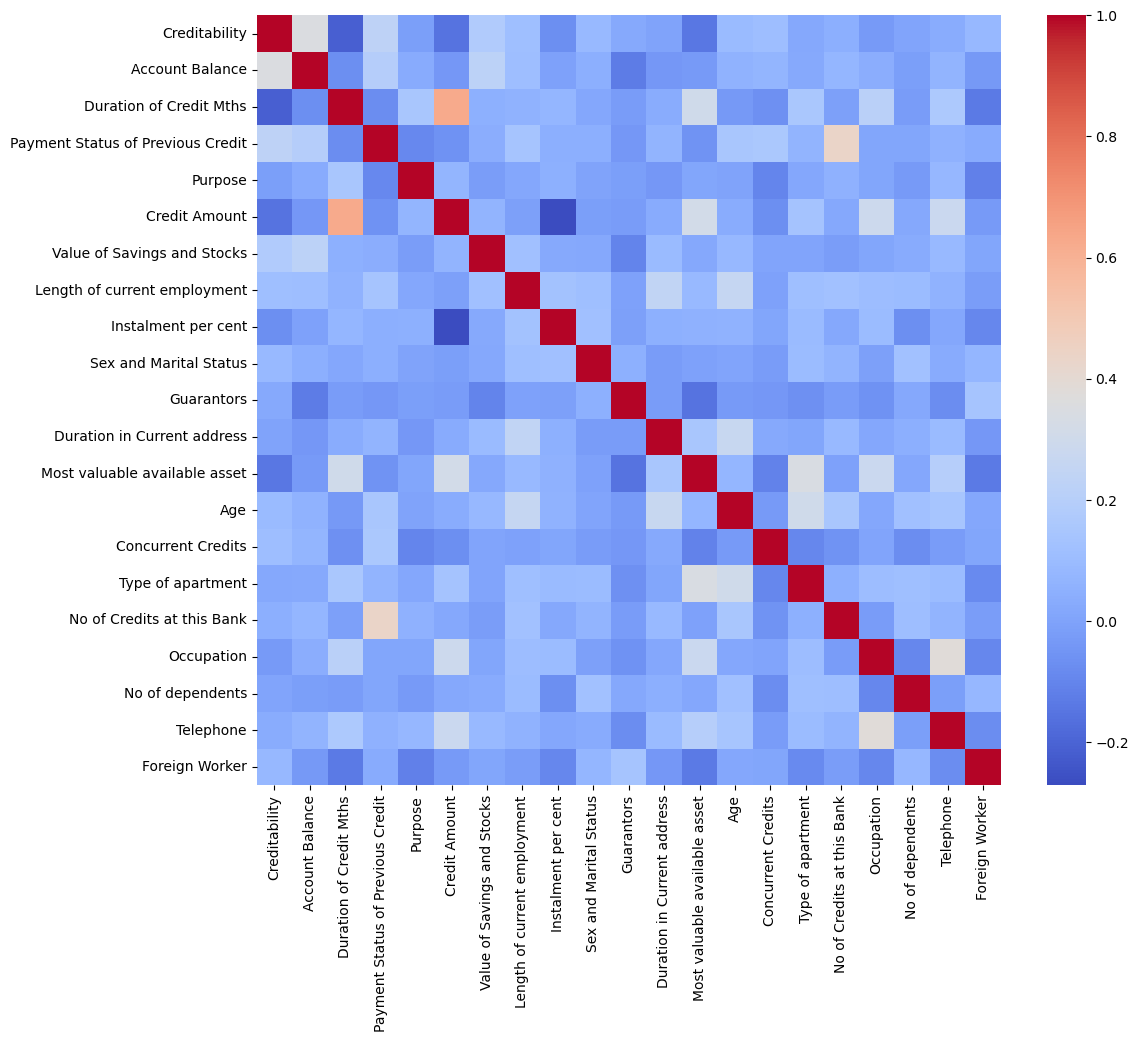

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

# This shows the relationship between variables.
# Darker colors mean stronger positive or negative correlation.

Creditability
1    700
0    300
Name: count, dtype: int64
Creditability
1    0.7
0    0.3
Name: proportion, dtype: float64


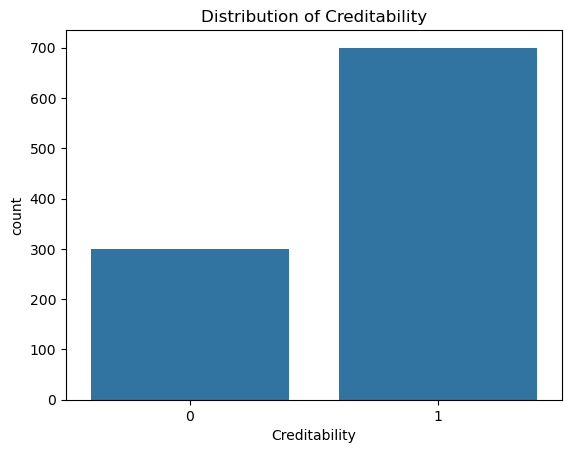

In [27]:
# Target distribution
print(df["Creditability"].value_counts())
print(df["Creditability"].value_counts(normalize=True))

sns.countplot(x="Creditability", data=df)
plt.title("Distribution of Creditability")
plt.show()


Duration of Credit Mths             -0.214927
Credit Amount                       -0.154740
Most valuable available asset       -0.142612
Instalment per cent                 -0.072404
Occupation                          -0.032735
Purpose                             -0.017979
Duration in Current address         -0.002967
No of dependents                     0.003015
Type of apartment                    0.018119
Guarantors                           0.025137
Telephone                            0.036466
No of Credits at this Bank           0.045732
Foreign Worker                       0.082079
Sex and Marital Status               0.088184
Age                                  0.091272
Concurrent Credits                   0.109844
Length of current employment         0.116002
Value of Savings and Stocks          0.178943
Payment Status of Previous Credit    0.228785
Account Balance                      0.350847
Creditability                        1.000000
Name: Creditability, dtype: float6

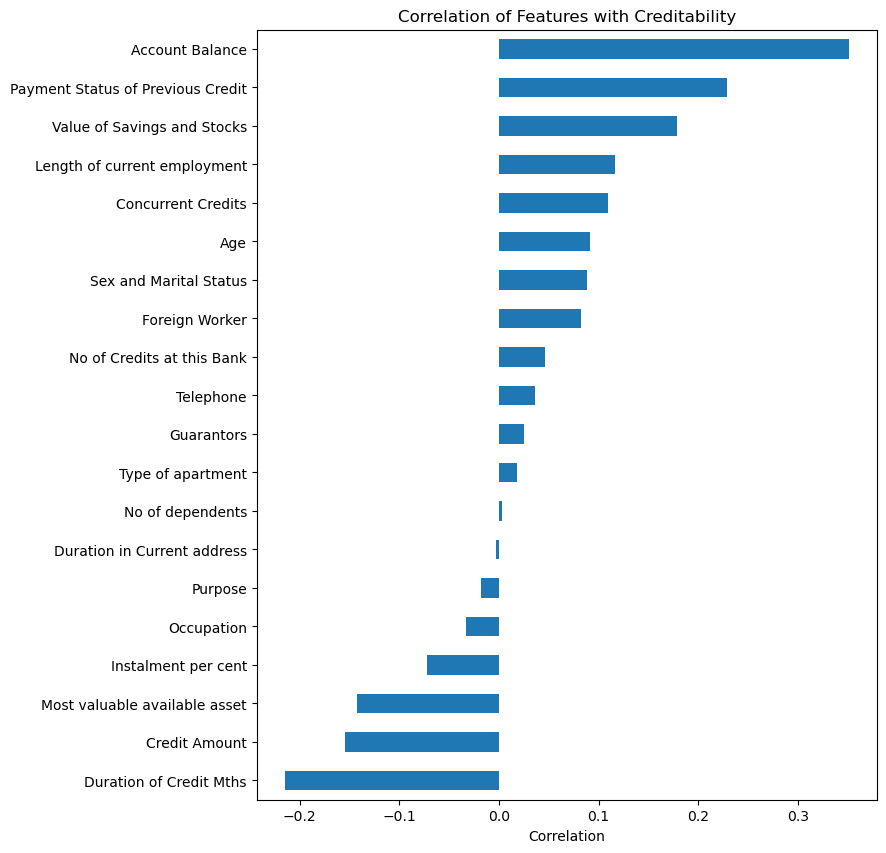

In [28]:
# Correlation with target
corr = df.corr(numeric_only=True)["Creditability"].sort_values()
print(corr)

plt.figure(figsize=(8,10))
corr.drop("Creditability").plot(kind="barh")
plt.title("Correlation of Features with Creditability")
plt.xlabel("Correlation")
plt.show()


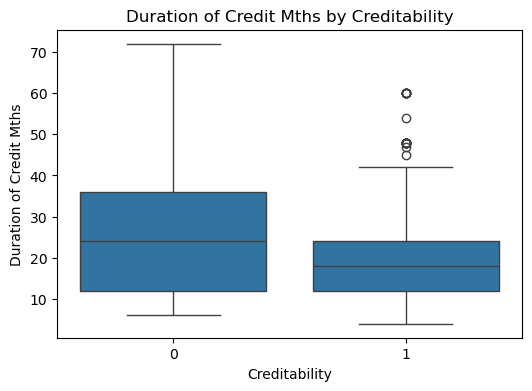

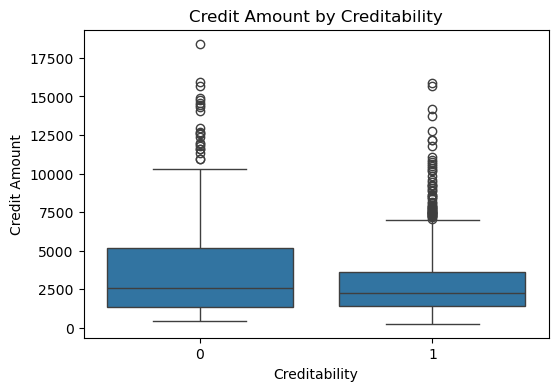

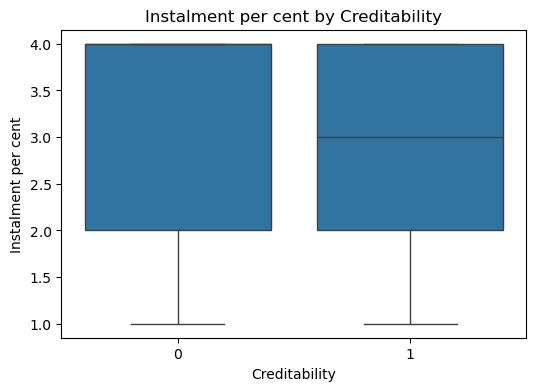

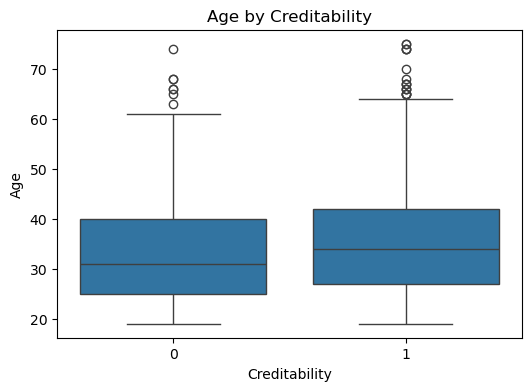

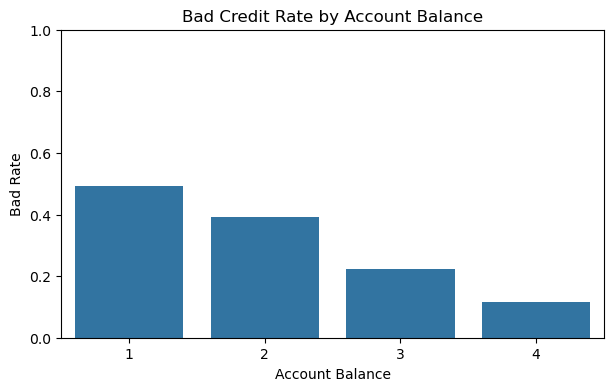


Bad credit rate by Account Balance
   Account Balance  Bad Rate
0                1  0.492701
1                2  0.390335
2                3  0.222222
3                4  0.116751


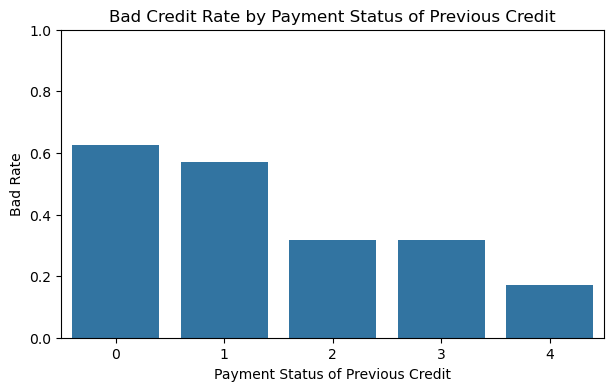


Bad credit rate by Payment Status of Previous Credit
   Payment Status of Previous Credit  Bad Rate
0                                  0  0.625000
1                                  1  0.571429
2                                  2  0.318868
3                                  3  0.318182
4                                  4  0.170648


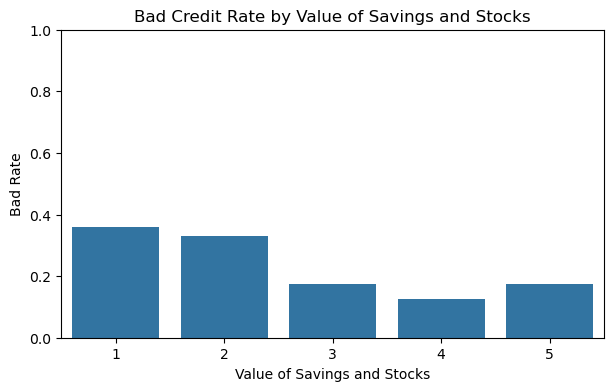


Bad credit rate by Value of Savings and Stocks
   Value of Savings and Stocks  Bad Rate
0                            1  0.359867
1                            2  0.330097
2                            3  0.174603
3                            4  0.125000
4                            5  0.174863


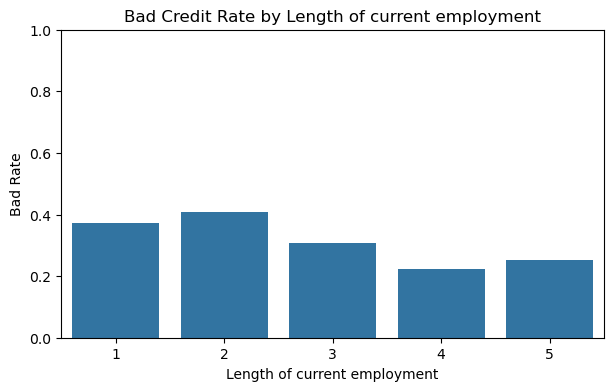


Bad credit rate by Length of current employment
   Length of current employment  Bad Rate
0                             1  0.370968
1                             2  0.406977
2                             3  0.306785
3                             4  0.224138
4                             5  0.252964


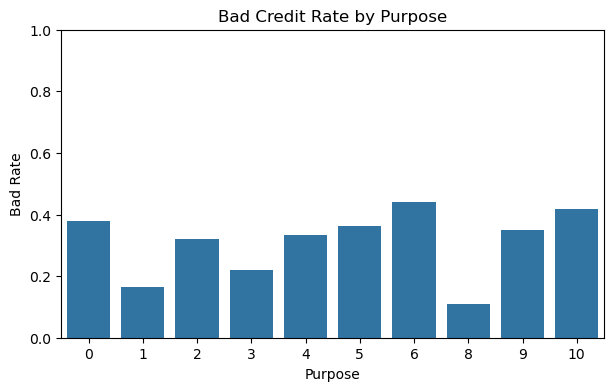


Bad credit rate by Purpose
   Purpose  Bad Rate
0        0  0.380342
1        1  0.165049
2        2  0.320442
3        3  0.221429
4        4  0.333333
5        5  0.363636
6        6  0.440000
7        8  0.111111
8        9  0.350515
9       10  0.416667


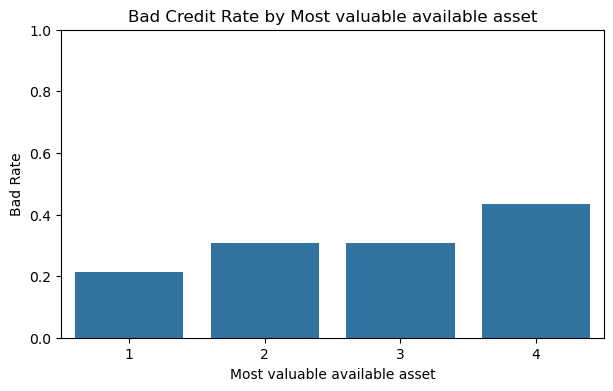


Bad credit rate by Most valuable available asset
   Most valuable available asset  Bad Rate
0                              1  0.212766
1                              2  0.306034
2                              3  0.307229
3                              4  0.435065


In [29]:
# Compare means for selected numeric features
numeric_features = ["Duration of Credit Mths", "Credit Amount", "Instalment per cent", "Age"]

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Creditability", y=col, data=df)
    plt.title(f"{col} by Creditability")
    plt.show()

# Bad credit rate by category
categorical_features = [
    "Account Balance",
    "Payment Status of Previous Credit",
    "Value of Savings and Stocks",
    "Length of current employment",
    "Purpose",
    "Most valuable available asset"
]

for col in categorical_features:
    temp = df.groupby(col)["Creditability"].mean().reset_index()
    temp["Bad Rate"] = 1 - temp["Creditability"]
    
    plt.figure(figsize=(7,4))
    sns.barplot(x=col, y="Bad Rate", data=temp)
    plt.title(f"Bad Credit Rate by {col}")
    plt.ylim(0, 1)
    plt.show()
    
    print(f"\nBad credit rate by {col}")
    print(temp[[col, "Bad Rate"]])

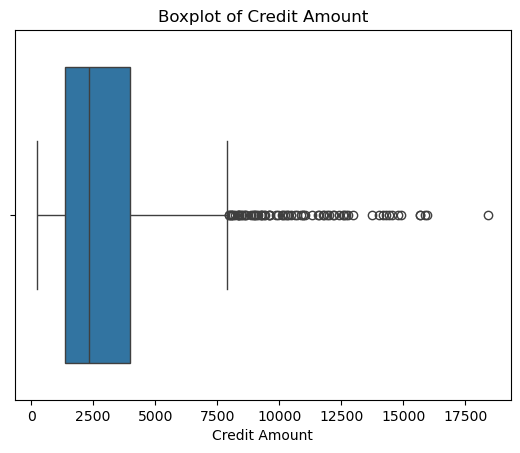

In [30]:
sns.boxplot(x=df["Credit Amount"])
plt.title("Boxplot of Credit Amount")
plt.show()

# This helps check the spread and possible outliers in Credit Amount.

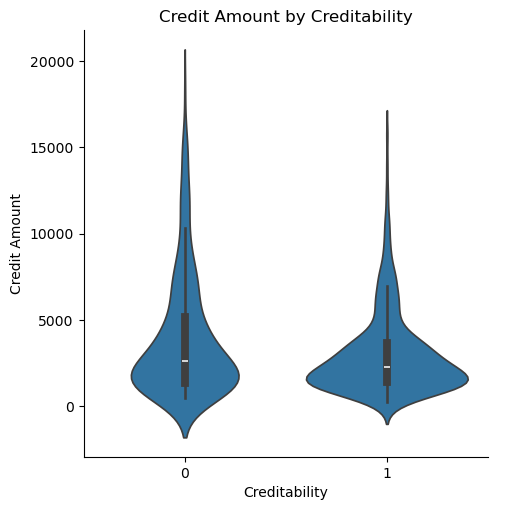

In [31]:
sns.catplot(data=df, x="Creditability", y="Credit Amount", kind="violin")
plt.title("Credit Amount by Creditability")
plt.show()

# This compares the distribution of Credit Amount for good and bad credit groups.

In [32]:
# One-hot encode categorial columns
df = pd.get_dummies(
    df,
    columns=[
        "Payment Status of Previous Credit",
        "Purpose",
        "Most valuable available asset",
        "Occupation",
        "Telephone",
        "Foreign Worker",
        "Sex and Marital Status",
        "Account Balance"
    ]
)

df.head()

,Creditability,Duration of Credit Mths,Credit Amount,Value of Savings and Stocks,Length of current employment,Instalment per cent,Guarantors,Duration in Current address,Age,Concurrent Credits,...,Foreign Worker_1,Foreign Worker_2,Sex and Marital Status_1,Sex and Marital Status_2,Sex and Marital Status_3,Sex and Marital Status_4,Account Balance_1,Account Balance_2,Account Balance_3,Account Balance_4
0,1,18,1049,1,2,4,1,4,21,3,...,True,False,False,True,False,False,True,False,False,False
1,1,9,2799,1,3,2,1,2,36,3,...,True,False,False,False,True,False,True,False,False,False
2,1,12,841,2,4,2,1,4,23,3,...,True,False,False,True,False,False,False,True,False,False
3,1,12,2122,1,3,3,1,2,39,3,...,False,True,False,False,True,False,True,False,False,False
4,1,12,2171,1,3,4,1,4,38,1,...,False,True,False,False,True,False,True,False,False,False


## Train-Test Split

In [33]:
X = df.drop(columns="Creditability")
Y = df["Creditability"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [34]:
# standardising credit amount

X_train["Credit Amount"] = stats.zscore(X_train["Credit Amount"])
X_test["Credit Amount"] = stats.zscore(X_test["Credit Amount"])

# This rescales Credit Amount so it has a mean near 0 and standard deviation near 1.
# It helps some models perform better.

## Model 1: Logistic Regression

In [35]:
model1 = linear_model.LogisticRegression(max_iter=2000)
model1.fit(X_train, Y_train)

pred1 = model1.predict(X_test)

cm1 = confusion_matrix(Y_test, pred1)
print(cm1)
print("Accuracy is", (cm1[0, 0] + cm1[1, 1]) / cm1.sum())

[[ 39  36]
 [ 21 154]]
Accuracy is 0.772


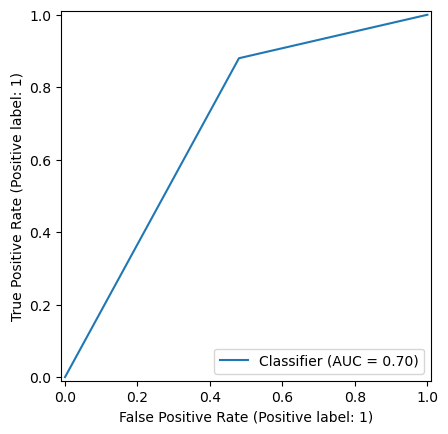

In [36]:
# ROC curve
RocCurveDisplay.from_predictions(Y_test, pred1)
plt.show()

# This shows how well the model separates the two classes.

# Model 2: Decision Tree

In [37]:
model2 = tree.DecisionTreeClassifier()
model2.fit(X_train, Y_train)

pred2 = model2.predict(X_test)

cm2 = confusion_matrix(Y_test, pred2)
print(cm2)
print("Accuracy is", (cm2[0, 0] + cm2[1, 1]) / cm2.sum())

# Decision Tree makes decisions based on feature splits.

[[ 30  45]
 [ 39 136]]
Accuracy is 0.664


# Model 3: Random Forest

In [38]:
model3 = ensemble.RandomForestClassifier()
model3.fit(X_train, Y_train)

pred3 = model3.predict(X_test)

cm3 = confusion_matrix(Y_test, pred3)
print(cm3)
print("Accuracy is", (cm3[0, 0] + cm3[1, 1]) / cm3.sum())

# Random Forest combines many decision trees to improve performance.

[[ 30  45]
 [ 18 157]]
Accuracy is 0.748


In [39]:
# Feature importance
fr = model3.feature_importances_
print(fr)

for importance, name in sorted(zip(model3.feature_importances_, X_train.columns), reverse=True)[:5]:
    print(name, importance)

# This shows the top 5 most important variables in the Random Forest model.

[0.09564234 0.10739889 0.0426038  0.04312499 0.04043564 0.01489506
 0.03152276 0.09016464 0.01812322 0.02271535 0.02161976 0.01021331
 0.01282838 0.01450814 0.0135884  0.00997223 0.02046861 0.01924707
 0.01279337 0.01438318 0.01502165 0.00246379 0.0047331  0.00969141
 0.00089724 0.00720708 0.00203163 0.01596149 0.01610568 0.01558872
 0.01230166 0.00260362 0.01069511 0.0166141  0.01378796 0.0150849
 0.01503321 0.00288061 0.00340669 0.00784632 0.01639523 0.01742232
 0.0087022  0.04037649 0.01846996 0.00856209 0.04386658]
Credit Amount 0.10739888992548084
Duration of Credit Mths 0.09564233794549945
Age 0.09016464216645179
Account Balance_4 0.04386658079350047
Length of current employment 0.04312498798220854


# Model 4: Gradient Boosting

In [40]:
model4 = ensemble.GradientBoostingClassifier()
model4.fit(X_train, Y_train)

pred4 = model4.predict(X_test)

cm4 = confusion_matrix(Y_test, pred4)
print(cm4)
print("Accuracy is", (cm4[0, 0] + cm4[1, 1]) / cm4.sum())

# Gradient Boosting builds trees step by step to correct previous errors.

[[ 41  34]
 [ 24 151]]
Accuracy is 0.768


## Model 5: Neural Network (MLP)

In [41]:
model5 = neural_network.MLPClassifier()
model5.fit(X_train, Y_train)

pred5 = model5.predict(X_test)

cm5 = confusion_matrix(Y_test, pred5)
print(cm5)
print("Accuracy is", (cm5[0, 0] + cm5[1, 1]) / cm5.sum())

# MLPClassifier is a simple neural network model from sklearn.

[[ 42  33]
 [ 31 144]]
Accuracy is 0.744


c:\Users\jerch\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
